In [2]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:

%autoreload 2
%aimport sog1_helpers

import pandas as pd
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import metapredict as meta

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [5]:
seq_lib = pd.read_csv("../data/visit2_seq_lib.csv", index_col = 0)
seq_lib

,Start,End,ProteinSeq,Description,Other
0,NaN,NaN,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0
1,NaN,NaN,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0
2,NaN,NaN,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0
3,NaN,NaN,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0
4,NaN,NaN,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_WLF_A_0,GCN4_CAAD40_WLF_A_0
...,...,...,...,...,...
23344,361,400,EALSLCDDLDDEQDREENTNSGSLKDKQPCIADYAHLGPE,37_PSvsCHA_hyperE_DD_all,/
23345,371,410,DEQDREEDTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,38_PSvsCHA_hyperE_DD_all,/
23346,391,430,IADYAHLGPEDFKRDLEECQKIVLDPSNDEDDEPPEDRDE,40_PSvsCHA_hyperE_DD_all,Pro subst
23347,401,440,DFKRDLEECQKIVLDPSNDEDDEPPEFRDEQDEFDEQDDF,41_PSvsCHA_hyperE_DD_all,Pro subst


In [6]:
controls = seq_lib.iloc[:37,]
controls

,Start,End,ProteinSeq,Description,Other
0,NaN,NaN,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0
1,NaN,NaN,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0
2,NaN,NaN,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0
3,NaN,NaN,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0
4,NaN,NaN,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_WLF_A_0,GCN4_CAAD40_WLF_A_0
5,NaN,NaN,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_MFYL_A_0,GCN4_CAAD40_MFYL_A_0
6,NaN,NaN,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_7As_0,GCN4_CAAD40_7As_0
7,NaN,NaN,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,Cterm_0,War1_Cterm_0
8,NaN,NaN,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,alt_0,GCN4alt_0
9,NaN,NaN,DDAVVESAASSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,alt_FF_AA_0,GCN4alt_FF_AA_0


In [12]:
activities = pd.read_csv("../output/SK_recalc_scores.csv")
activities

,Unnamed: 0,ProteinSeq,Activity_S3_1,Error,BC Count
0,0,AAAAAAAAAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,247.596326,NaN,1
1,1,AAAAAAAACQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2420.236680,NaN,1
2,2,AAAAAAAAGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,544.103037,NaN,1
3,3,AAAAAAAANIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,391.240450,NaN,1
4,4,AAAAAHLGPEDFKRDLEECQAAAADPSNIELDTPPEFRLS,428.387407,192.551180,2
...,...,...,...,...,...
6788,6788,YSLFDDPSEGYETDPLFNTNDDLDDSNGWYSLFPPTTTSS,1627.763143,NaN,1
6789,6789,YSLFDSPSEGYETDPLFNTNDDLDDSNGWYSLFPPTTTSS,3249.679912,3714.542390,2
6790,6790,YSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCK,1304.650547,2097.495254,6
6791,6791,YSTGTRKRRKILDDDLGDVRWHKTGRTKPVILDGVQRGCK,2263.458216,1474.154509,2


<Axes: xlabel='Activity_S3_1', ylabel='Count'>

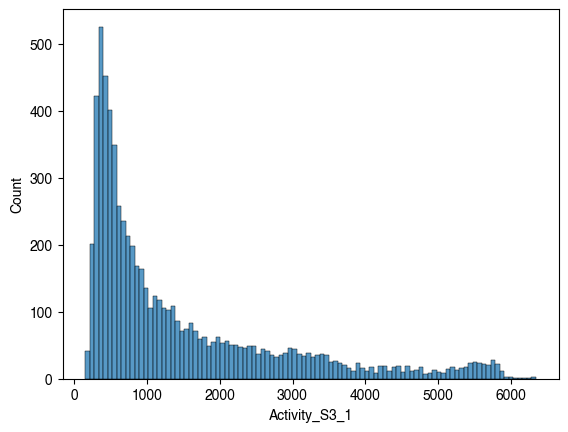

In [13]:
sns.histplot(activities["Activity_S3_1"], bins = 100)

In [14]:
control_activities = pd.merge(controls, activities, on = "ProteinSeq")
control_activities

,Start,End,ProteinSeq,Description,Other,Unnamed: 0,Activity_S3_1,Error,BC Count
0,NaN,NaN,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0,6395,4488.479210,1087.082399,10
1,NaN,NaN,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0,6394,3014.428134,3952.233952,2
2,NaN,NaN,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0,6393,439.992242,NaN,1
3,NaN,NaN,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0,6385,2559.269908,998.257989,13
4,NaN,NaN,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_MFYL_A_0,GCN4_CAAD40_MFYL_A_0,6381,759.701800,NaN,1
5,NaN,NaN,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_7As_0,GCN4_CAAD40_7As_0,6380,603.547486,812.645695,14
6,NaN,NaN,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,Cterm_0,War1_Cterm_0,5102,4943.929742,1739.136071,13
7,NaN,NaN,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,alt_0,GCN4alt_0,372,4316.725533,2222.138487,12
8,NaN,NaN,DDAVVESFFSSSTDSTPAAEAENAEDNSKEWTSLFDNDIP,alt_MFYL_A_0,GCN4alt_MFYL_A_0,370,908.475014,NaN,1
9,NaN,NaN,DDAVVESFFSSSTDSTPMFEYENLEDNSKEATSAADNDIP,alt_WLF_A_0,GCN4alt_WLF_A_0,371,805.025764,NaN,1


In [40]:
control_activities["Control Type"] = [True, False, False, True, False, False, True, True, False, False, True, False, False, False, True, False, False, False, False, False,-1,-1,-1,-1,-1]
control_activities["Control Type"] = control_activities["Control Type"].map({True : "Positive", False : "Negative",-1: "Unknown"})
control_activities[["Other", "Control Type", "Activity_S3_1"]]

,Other,Control Type,Activity_S3_1
0,GAL4_AD1_0,Positive,4488.479210
1,GAL4_AD1_Aro2A_0,Negative,3014.428134
2,GAL4_AD1_L2A_0,Negative,439.992242
3,GCN4_CAAD40_0,Positive,2559.269908
4,GCN4_CAAD40_MFYL_A_0,Negative,759.701800
5,GCN4_CAAD40_7As_0,Negative,603.547486
6,War1_Cterm_0,Positive,4943.929742
7,GCN4alt_0,Positive,4316.725533
8,GCN4alt_MFYL_A_0,Negative,908.475014
9,GCN4alt_WLF_A_0,Negative,805.025764


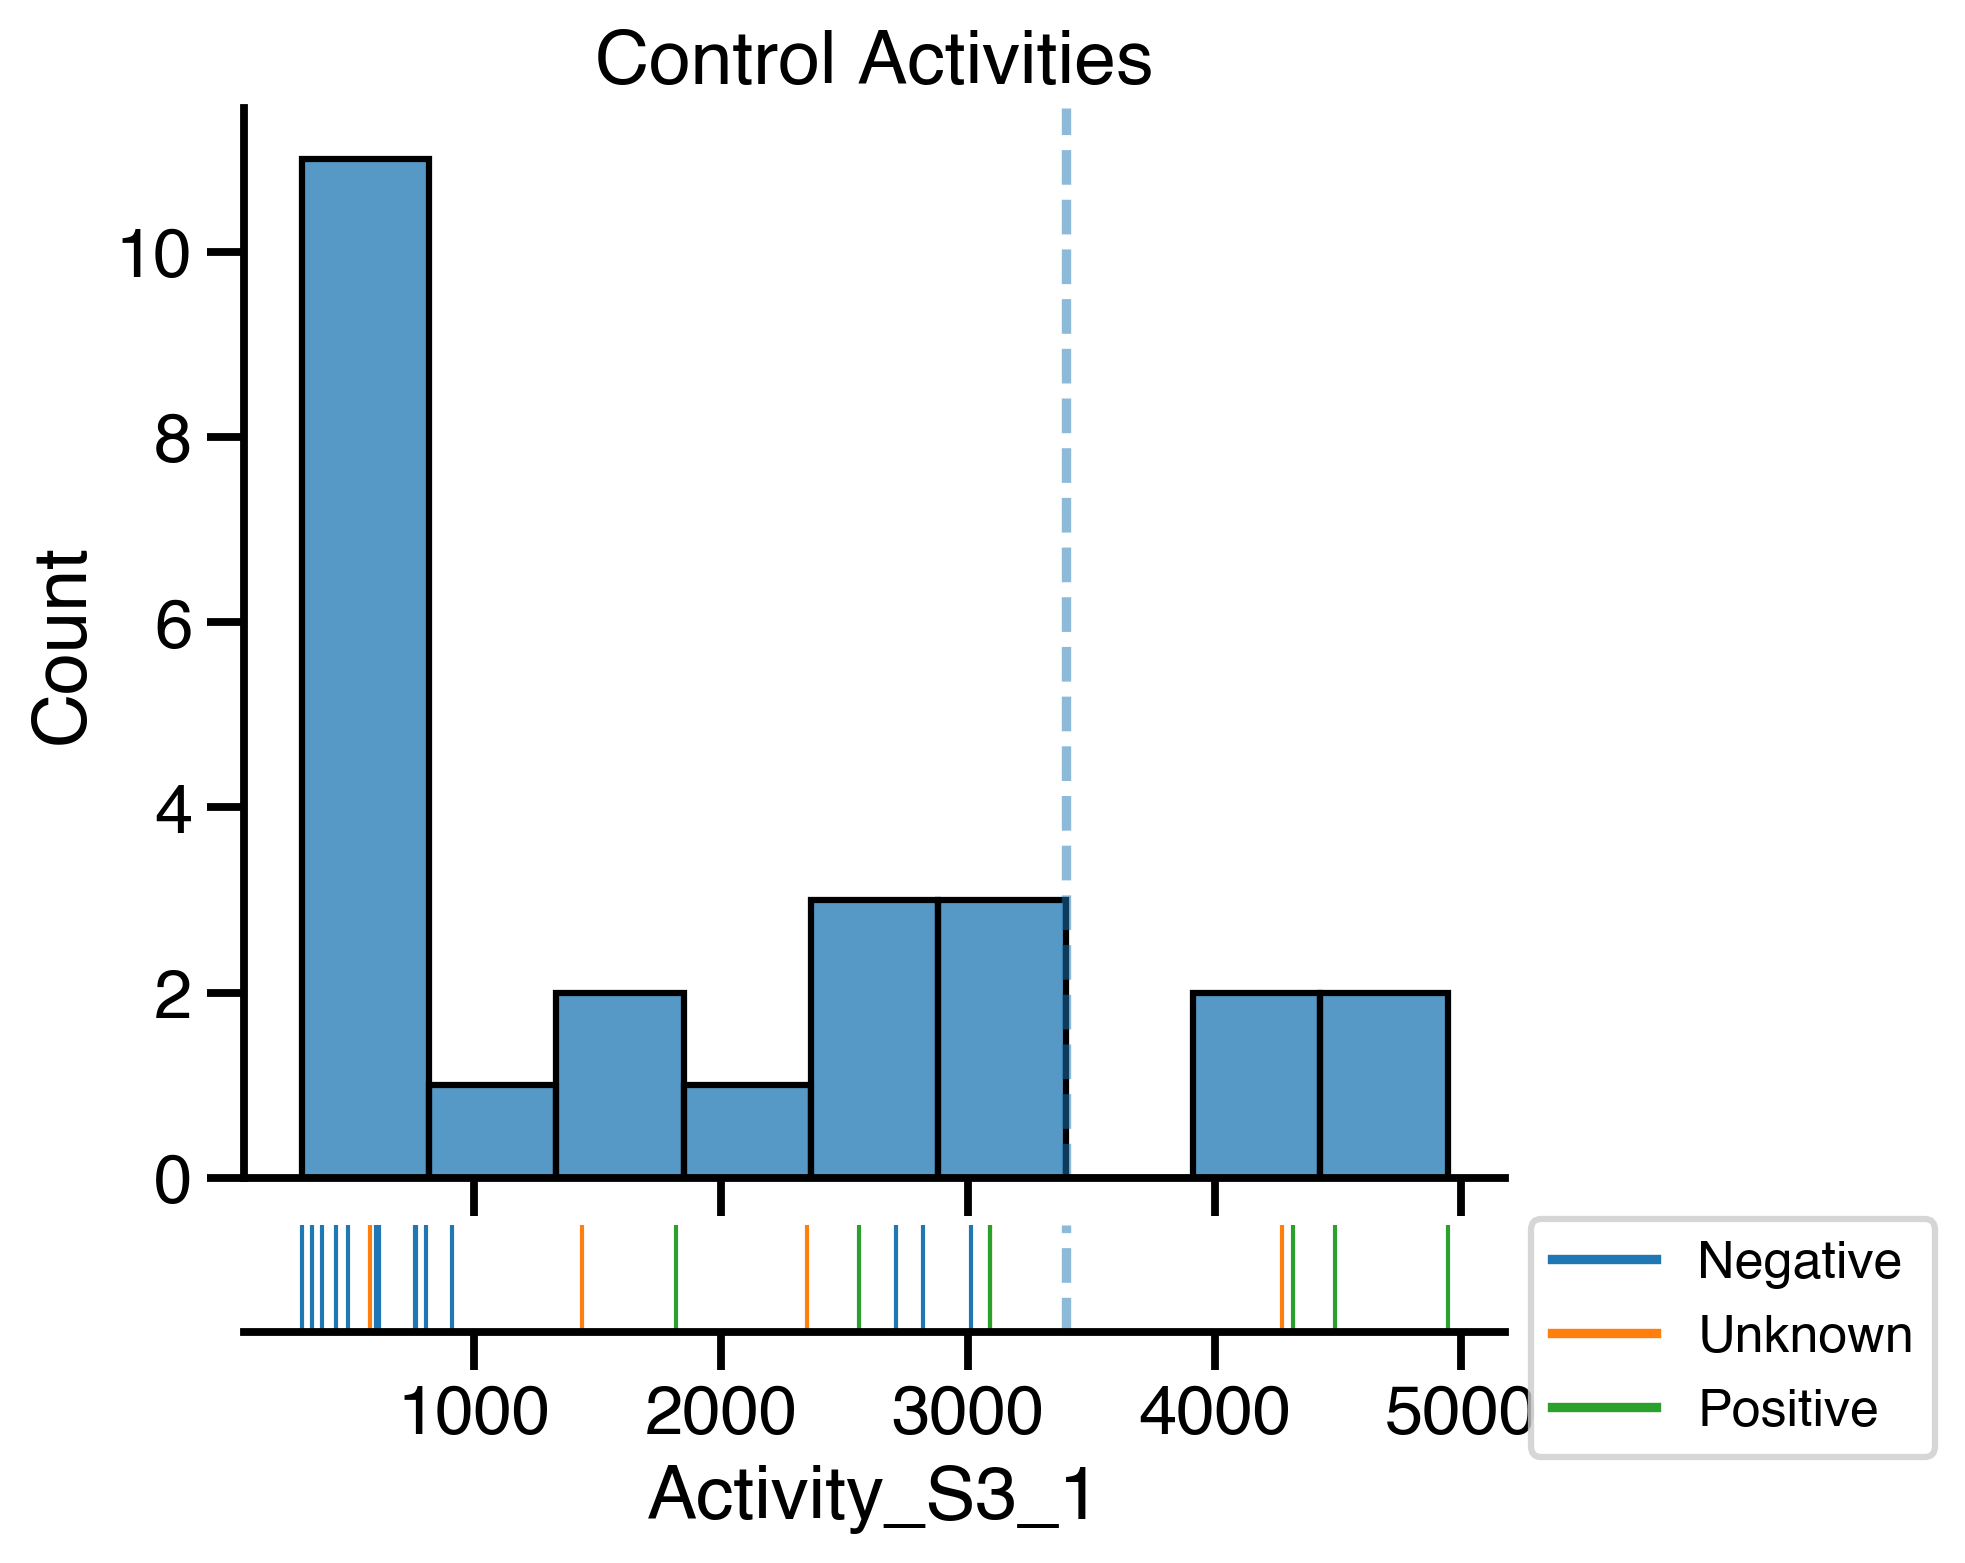

In [41]:
sorted_df = control_activities.sort_values(by = "Activity_S3_1").reset_index()


sns.set_context('talk')
fig, axs = plt.subplots(2, 1, height_ratios=(1, 0.1), sharex = True, dpi = 300)
sns.histplot(sorted_df["Activity_S3_1"], bins = 9, ax = axs[0])

ax = sns.rugplot(data = sorted_df, x = "Activity_S3_1", ax = axs[1], height = 1, hue = "Control Type")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1.3), fontsize = 'x-small', title = None)

sns.despine()
sns.despine(ax = axs[1], left = True)
axs[1].set_yticks([])
plt.tight_layout(pad = 0.1)
axs[0].set_title("Control Activities")

for ax in axs:
    ax.axvline(3400, linestyle = 'dashed', alpha = 0.5)


In [42]:
control_activities.sort_values(by = "Activity_S3_1")

,Start,End,ProteinSeq,Description,Other,Unnamed: 0,Activity_S3_1,Error,BC Count,Control Type
12,NaN,NaN,YAIPENEAADEDTMNFISSAKNDASNISNSAPFEYPHEIA,L2A_0,Rap1_L2A_0,6759,300.574719,NaN,1,Negative
18,NaN,NaN,TDAIDEEVLMSLVIEMGLDRIKELPELALGQNEADAMTDA,ARO2A_0,CITED2_ARO2A_0,6403,342.680079,NaN,1,Negative
11,NaN,NaN,DSPGPGFTPHDSAPYGAIDMADFEFEQMFTDAIGIDEYGG,L2I_0,VP16C_L2I_0,1135,384.372622,NaN,1,Negative
2,NaN,NaN,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0,6393,439.992242,NaN,1,Negative
13,NaN,NaN,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,Aro2A_0,Rap1_Aro2A_0,51,487.823879,NaN,1,Negative
22,NaN,NaN,GPKTPEISSMLVNNNEASFVEETNAAKKLKPNSDESDDLM,291to330,RAP2.2_291-330,2806,576.680229,442.790776,19,Unknown
5,NaN,NaN,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_7As_0,GCN4_CAAD40_7As_0,6380,603.547486,812.645695,14,Negative
15,NaN,NaN,PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP,7As_0,VP16N_7As_0,5079,615.558281,791.920614,16,Negative
4,NaN,NaN,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_MFYL_A_0,GCN4_CAAD40_MFYL_A_0,6381,759.701800,NaN,1,Negative
16,NaN,NaN,PPTDVSLGDELHLDGEDVAMAHADALDDADLDMLGDGDSP,F442A_0,VP16N_F442A_0,5080,764.566247,544.857504,3,Negative


In [43]:
4488.479210 - 1087.082399

3401.3968110000005

[]

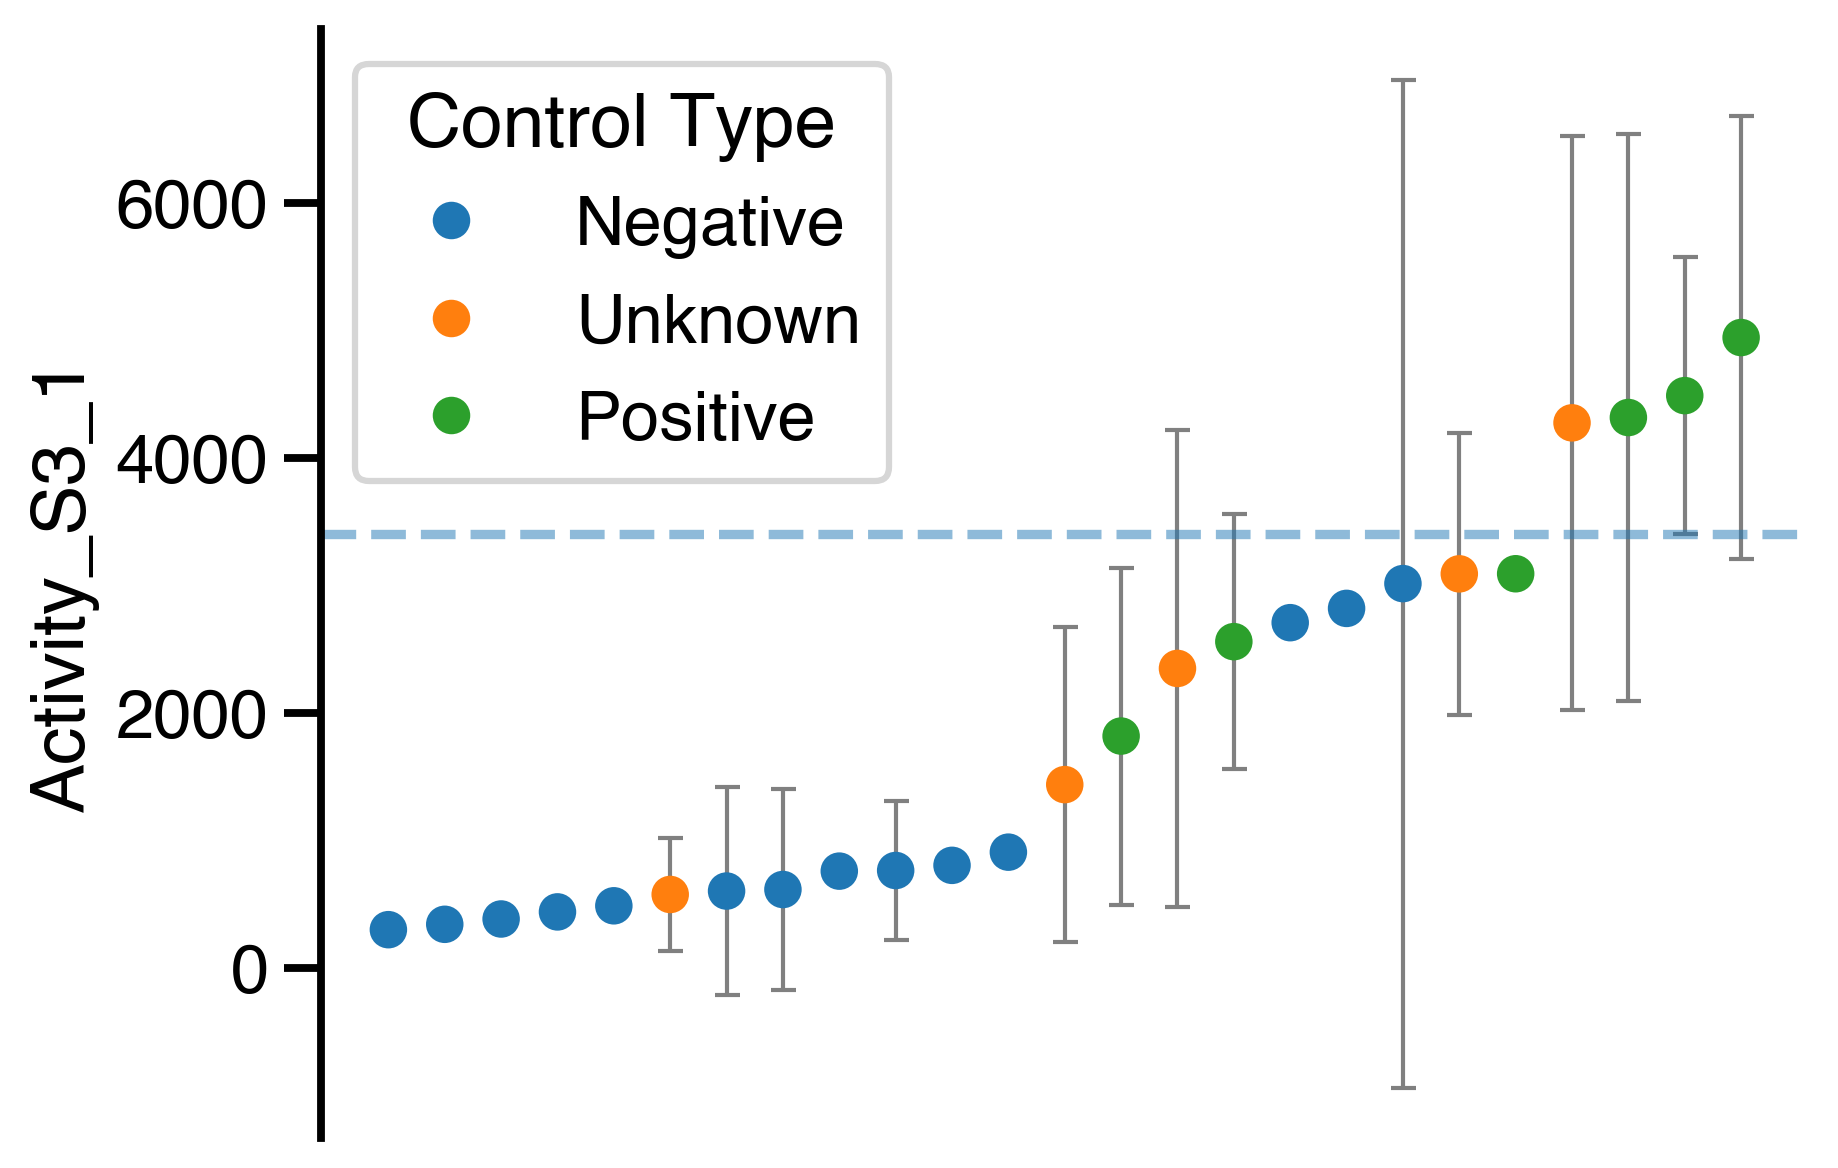

In [45]:
plt.figure(dpi = 300)

sorted_df = control_activities.sort_values(by = "Activity_S3_1").reset_index()


plt.errorbar(
    x=sorted_df.index,
    y=sorted_df["Activity_S3_1"],
    yerr=sorted_df["Error"],
    fmt='none',  # 'o' means circle markers
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label=None, zorder = 0
)

ax = sns.scatterplot(data = sorted_df, x = sorted_df.index, y = "Activity_S3_1", hue = "Control Type", zorder = 10, edgecolor = "None")

plt.axhline(3400, linestyle = 'dashed', alpha = 0.5)

sns.despine(bottom = True)
plt.xlabel("")
ax.set_xticks([])


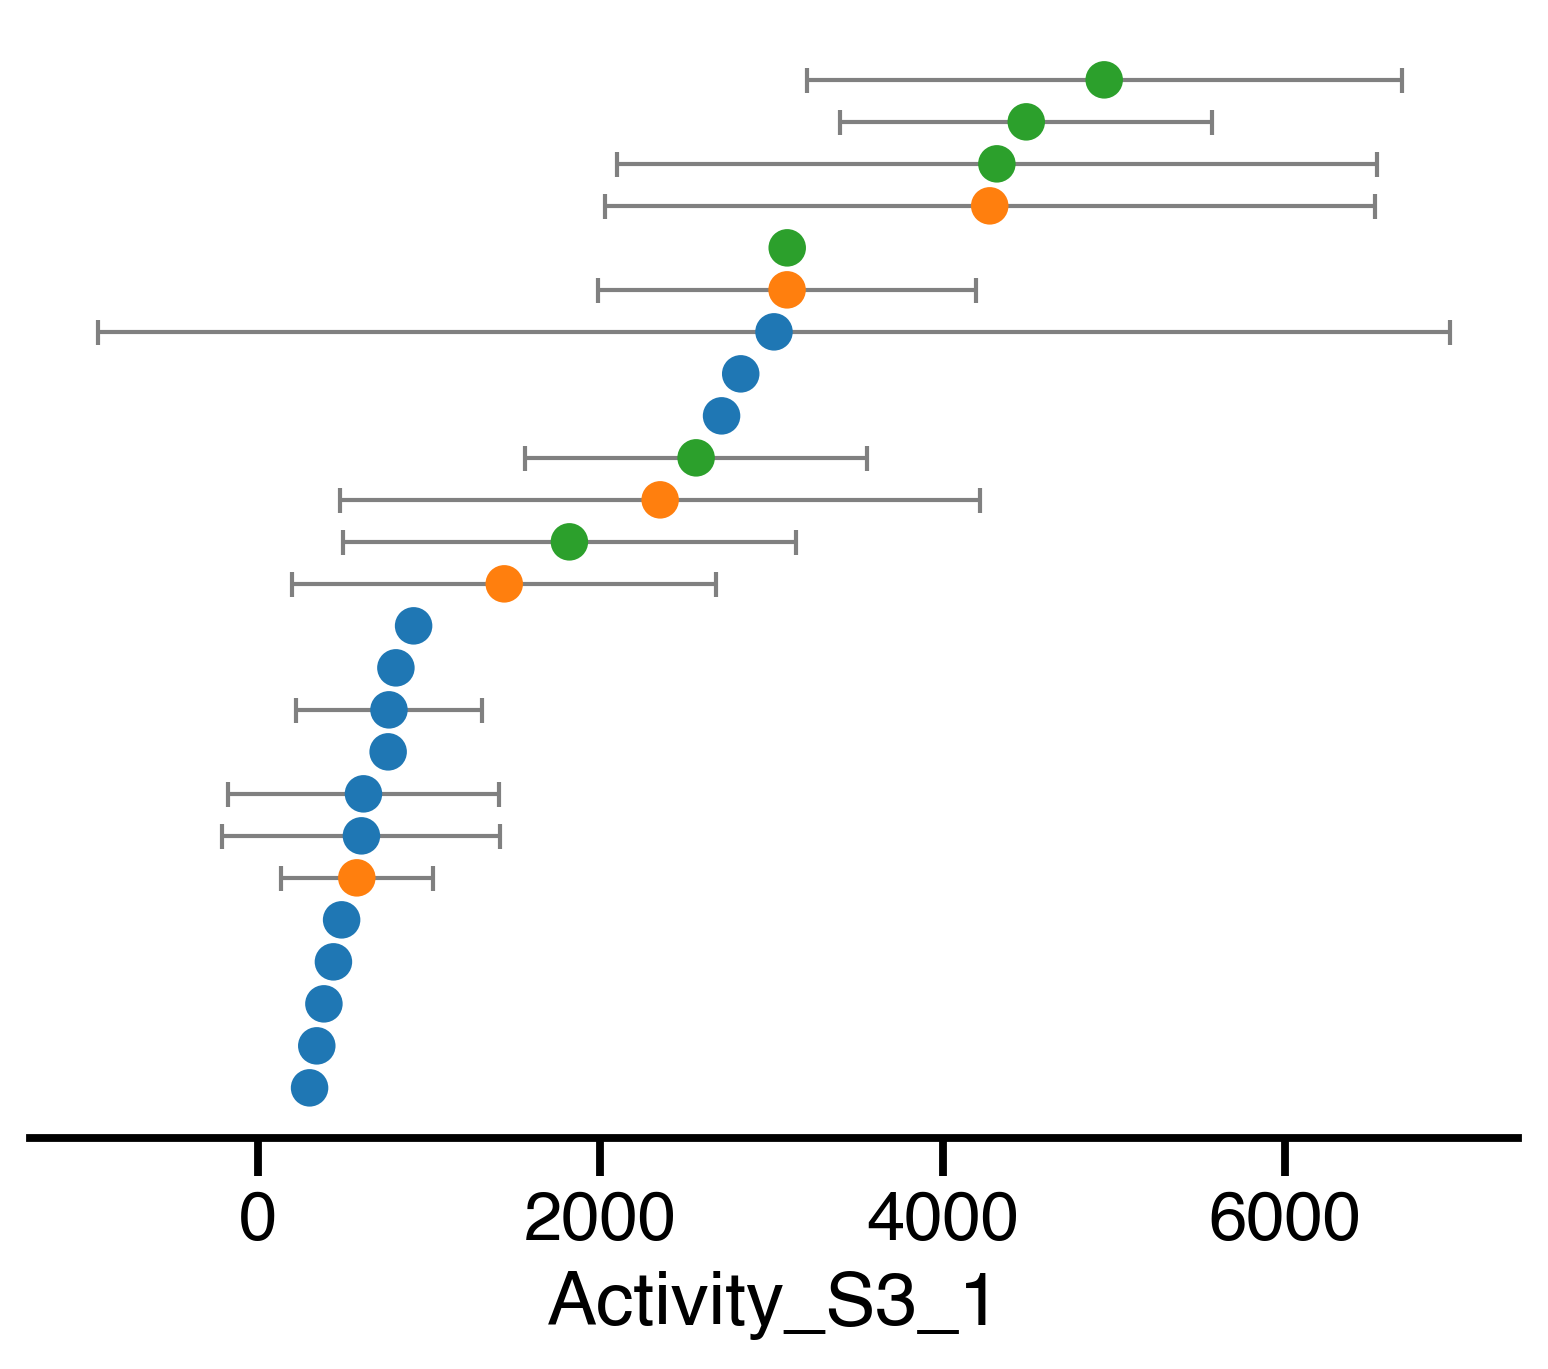

In [46]:

plt.figure(dpi=300)

# Sort and reset index
sorted_df = control_activities.sort_values(by="Activity_S3_1").reset_index()

# Error bars: activity on x-axis
plt.errorbar(
    x=sorted_df["Activity_S3_1"],
    y=sorted_df.index,
    xerr=sorted_df["Error"],
    fmt='none',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label=None,
    zorder=0
)

# Scatterplot: activity on x-axis
ax = sns.scatterplot(
    data=sorted_df,
    x="Activity_S3_1",
    y=sorted_df.index,
    hue="Control Type",
    zorder=10,
    edgecolor="None",
    legend=False
)

# Add vertical reference line (was horizontal before)
#plt.axvline(3400, linestyle='dashed', alpha=0.5)

# Clean up axes
sns.despine(left=True)
plt.ylabel("")            # Optional: remove y-axis label
ax.set_yticks([])         # Remove y-ticks

plt.show()


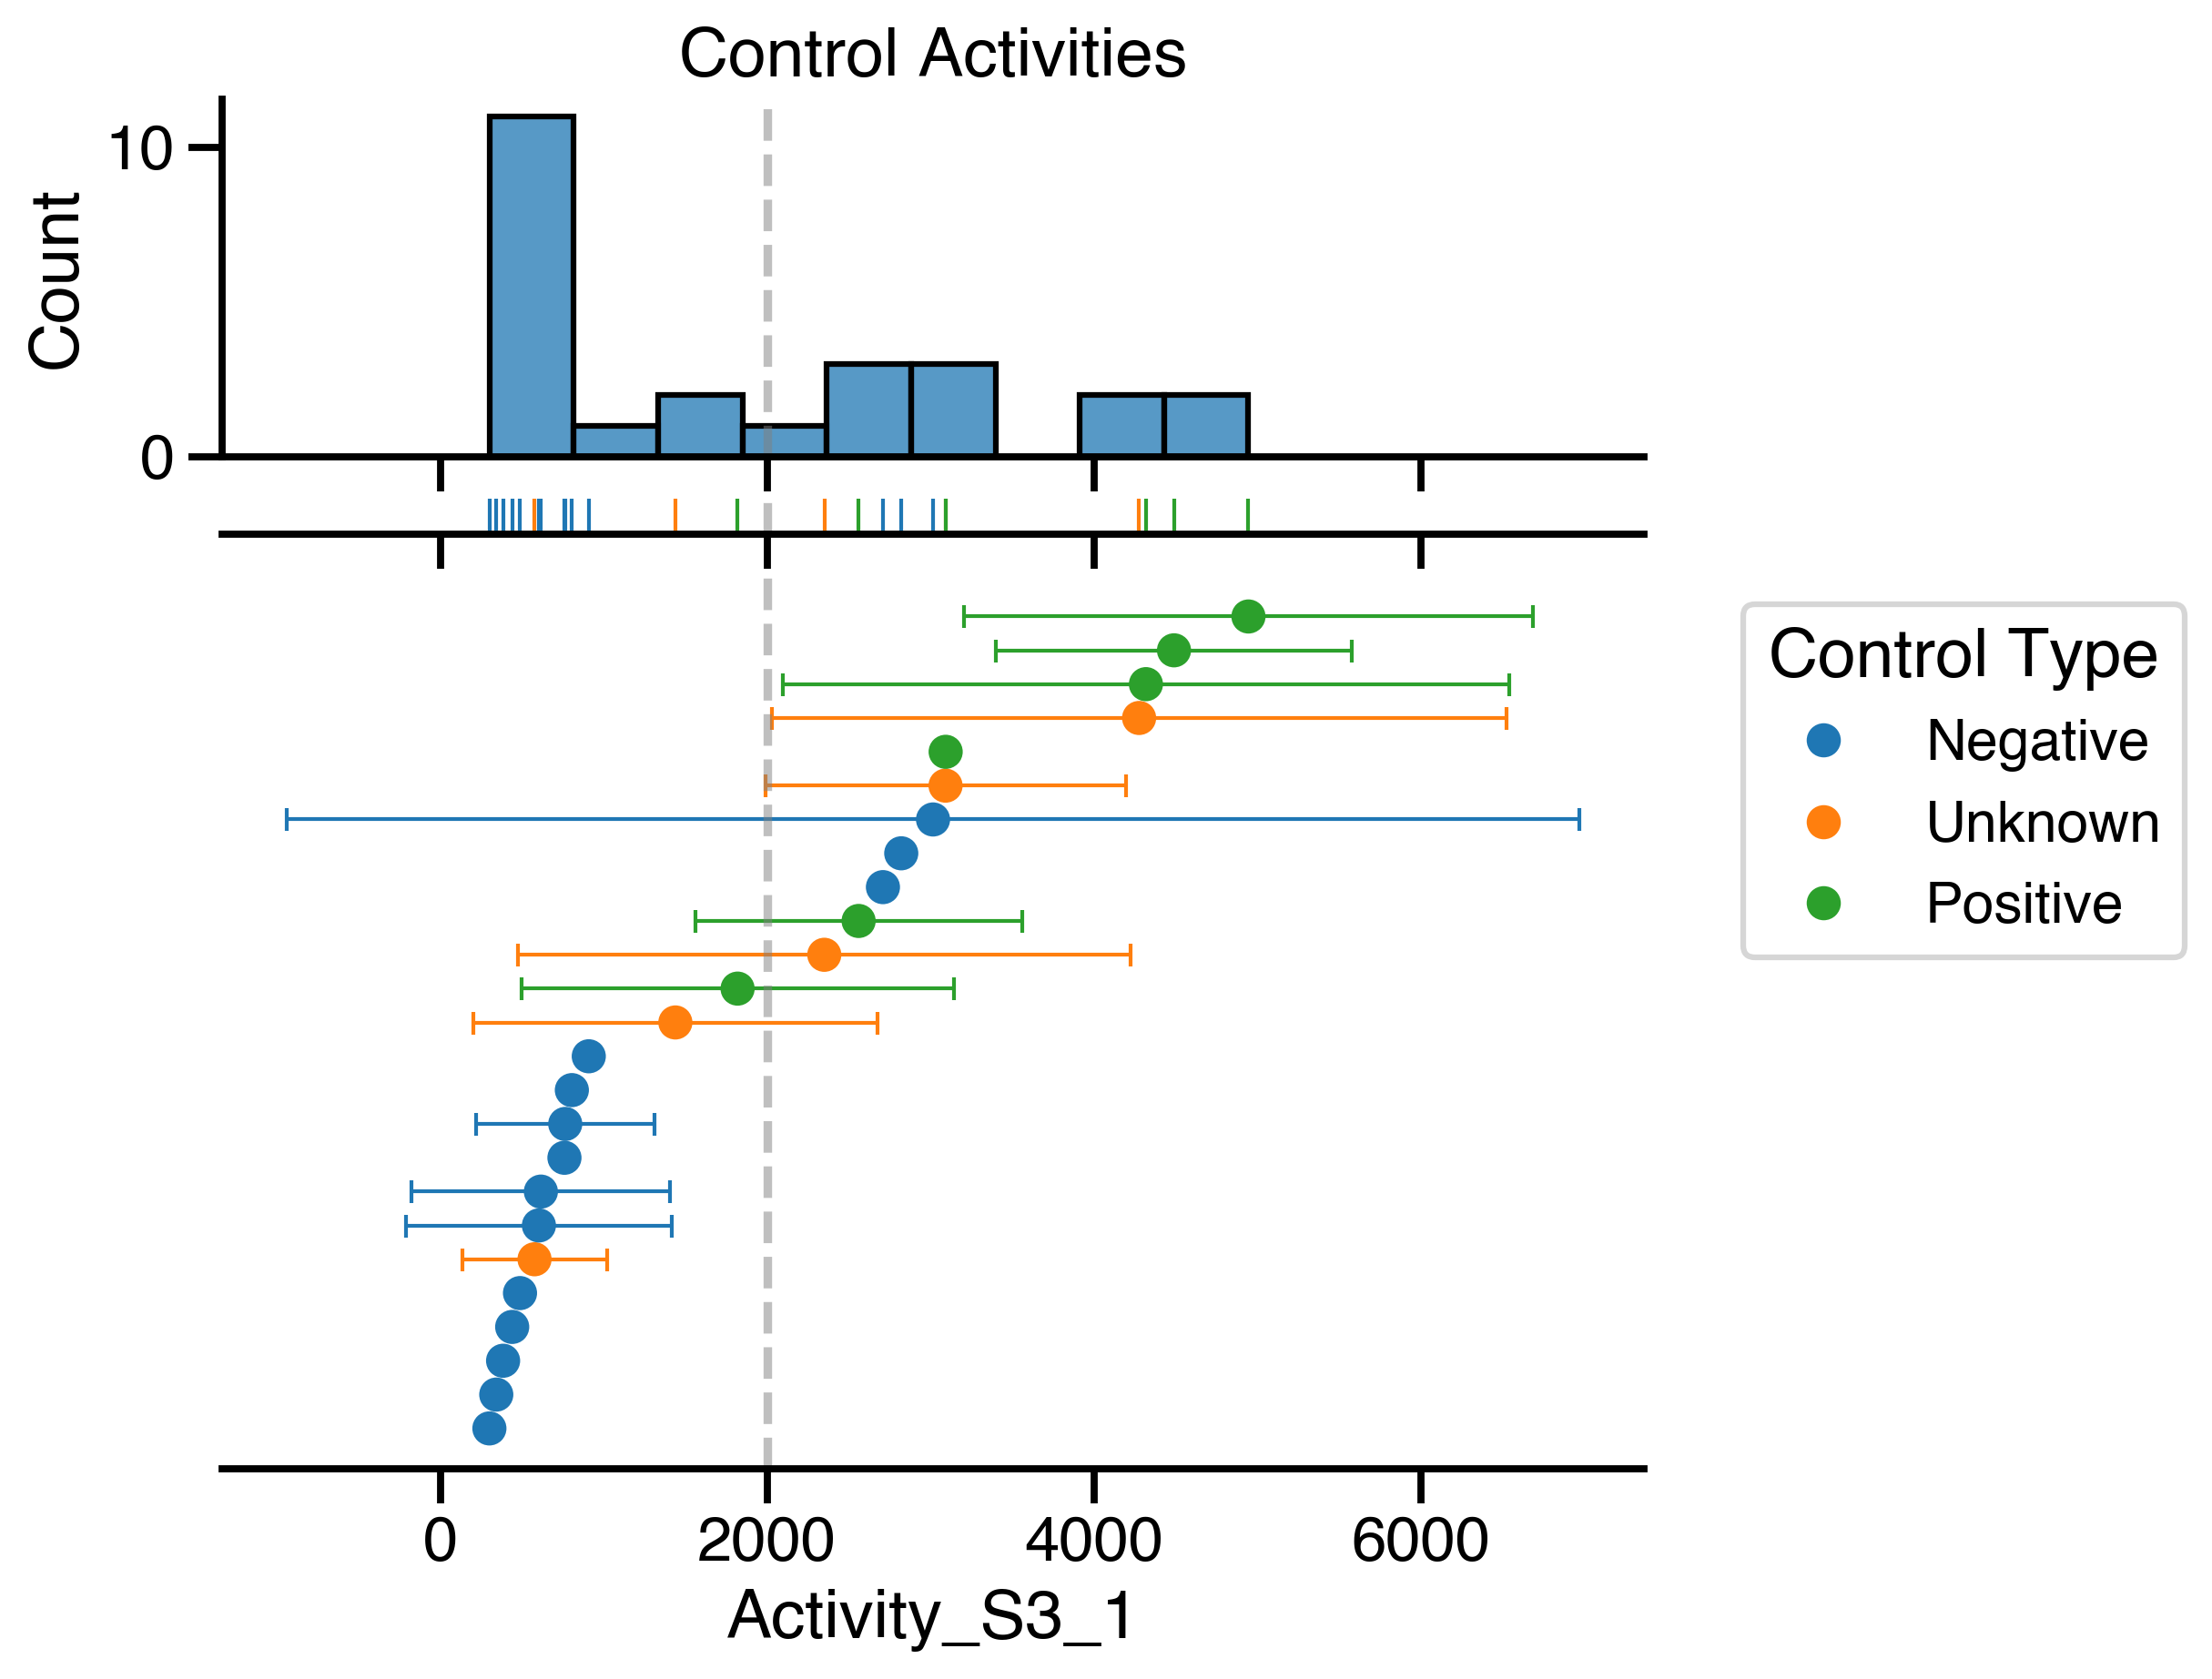

In [59]:
# Define a consistent color palette
palette = sns.color_palette("tab10", n_colors=sorted_df["Control Type"].nunique())

sns.set_context('talk')
fig, axs = plt.subplots(3, 1, height_ratios=(1, 0.1, 2.5), figsize=(8, 6), sharex=True, dpi=300)

# Histogram
sns.histplot(sorted_df["Activity_S3_1"], bins=9, ax=axs[0], color=palette[0])

# Rugplot
sns.rugplot(data=sorted_df, x="Activity_S3_1", ax=axs[1], height=1, hue="Control Type", palette=palette, legend=False)

sns.despine()
sns.despine(ax=axs[1], left=True)
axs[1].set_yticks([])
axs[0].set_title("Control Activities")

for ax in axs:
    ax.axvline(2000, linestyle='dashed', alpha=0.5, color = 'gray')

# Error bars: activity on x-axis
for control_type, color in zip(sorted_df["Control Type"].unique(), palette):
    subset = sorted_df[sorted_df["Control Type"] == control_type]
    axs[2].errorbar(
        x=subset["Activity_S3_1"],
        y=subset.index,
        xerr=subset["Error"],
        fmt='none',
        ecolor=color,
        elinewidth=1,
        capsize=3,
        label=None,
        zorder=0
    )

# Scatterplot: activity on x-axis
sns.scatterplot(
    data=sorted_df,
    x="Activity_S3_1",
    y=sorted_df.index,
    hue="Control Type",
    palette=palette,
    zorder=10,
    edgecolor="None",
    legend=True,
    ax=axs[2]
)
axs[2].legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
sns.despine(ax=axs[1], left=True)
sns.despine(ax=axs[2], left=True)

plt.ylabel("")  # Optional: remove y-axis label
axs[2].set_yticks([])  # Remove y-ticks

plt.tight_layout(pad=0.1)
plt.show()


In [ ]:
# Define a consistent color palette
palette = sns.color_palette("tab10", n_colors=sorted_df["Control Type"].nunique())

sns.set_context('talk')
fig, axs = plt.subplots(3, 1, height_ratios=(1, 0.1, 2.5), figsize=(8, 6), sharex=True, dpi=300)

# Histogram
sns.histplot(sorted_df["Activity_S3_1"], bins=9, ax=axs[0], color=palette[0])

# Rugplot
sns.rugplot(data=sorted_df, x="Activity_S3_1", ax=axs[1], height=1, hue="Control Type", palette=palette, legend=False)

sns.despine()
sns.despine(ax=axs[1], left=True)
axs[1].set_yticks([])
axs[0].set_title("Control Activities")

for ax in axs:
    ax.axvline(2000, linestyle='dashed', alpha=0.5)

# Error bars: activity on x-axis
for control_type, color in zip(sorted_df["Control Type"].unique(), palette):
    subset = sorted_df[sorted_df["Control Type"] == control_type]
    axs[2].errorbar(
        x=subset["Activity_S3_1"],
        y=subset.index,
        xerr=subset["Error"],
        fmt='none',
        ecolor=color,
        elinewidth=1,
        capsize=3,
        label=None,
        zorder=0
    )

# Scatterplot: activity on x-axis
sns.scatterplot(
    data=sorted_df,
    x="Activity_S3_1",
    y=sorted_df.index,
    hue="Control Type",
    palette=palette,
    zorder=10,
    edgecolor="None",
    legend=True,
    ax=axs[2]
)
axs[2].legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
sns.despine(ax=axs[1], left=True)
sns.despine(ax=axs[2], left=True)

plt.ylabel("")  # Optional: remove y-axis label
axs[2].set_yticks([])  # Remove y-ticks

plt.tight_layout(pad=0.1)
plt.show()
